# tRIBS-Sandbox: Run Model

The goal for this notebook is to first run the model we made then use pytRIBS to load in our model outputs and make some plots from the model outputs. The plots shown below are just examples and each output file has multiple variables that can be plotted. Addtion detail on the available model outputs is located [Here](https://tribshms.readthedocs.io/en/latest/man/Output.html)

## Imports

In [1]:
# note you can install pytRIBS via pip; see: https://pypi.org/project/pytRIBS/
from pytRIBS.classes import *

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# if you have installed pytRIBS, the following libraries should already be in your environment
import os, sys, shutil
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from shapely.ops import unary_union
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

### Run The Model
In our previous notebook we got everything organized to run the model. Typically tRIBS is ran from the command line but in this codespace we setup a direct path to the tRIBS executeable so we run the executeable from within this notebook. 

So lets run the simulation:

In [3]:
import time

# Define File Names
input_filename = 'SMF_continuous.in'  
log_filename   = 'simulation.log'

# Pre-run check
# Check if the input file actually exists before trying to run.
if not os.path.exists(input_filename):
    print(f"ERROR: Could not find input file: '{input_filename}'")
    print("Please check your spelling or ensure the previous pytRIBS step ran correctly.")
else:
    print(f"Found input file: {input_filename}")
    print(f"Starting tRIBS simulation...")
    print(f"Runtime output is being redirected to: {log_filename}")

    # Execute model
    # We use the 'time' module to track how long the simulation takes.
    start_time = time.time()
    
    # Run tRIBS! 
    # syntax: !tRIBS <input_file> > <log_file> 2>&1
    exit_code = os.system(f"tRIBS {input_filename} > {log_filename} 2>&1")
    
    end_time = time.time()
    duration = (end_time - start_time) / 60

    # Post-run report
    if exit_code == 0:
        print(f"\nSUCCESS: Simulation completed in {duration:.2f} minutes.")

Found input file: SMF_continuous.in
Starting tRIBS simulation...
Runtime output is being redirected to: simulation.log

SUCCESS: Simulation completed in 4.11 minutes.


## Results Class: Merge and Visualize Results
The Results class simplifies working with tRIBS outputs by offering post-processing methods that handle everything from file management to basic model output analysis. tRIBS generates a large amount of data with fine spatial and temporal resolutions, including time series of streamflow and spatially averaged state and flux variables. Additionally, the model produces Voronoi diagrams that can be used with both dynamic snapshots (captured at specific times) and integrated outputs (aggregated over the entire model run). The Results class helps manage these outputs, providing users with tools to merge parallel results and perform further analysis using commonly utilized data libraries.

In [4]:
name ='SMF_continuous'
epsg = 26912
proj = Project(os.getcwd(),name,epsg) 
# With this command below pytRIBS will read the input file to ge tthe filepaths of all output locations
results = Results('SMF_continuous.in',meta=proj.meta)

In [5]:
gdf = results.voronoi.merge(results.int_spatial_vars,on='ID')
results.get_mrf_results()
results.get_element_results()

strmflw_sim_raw = results.get_qout_results()
mrf = results.mrf['mrf']
mrf.set_index('Time',inplace=True)

Reading in: SMF_continuous1547.pixel
Reading in: SMF_continuous1960.pixel
Reading in: SMF_100yr3082.pixel
Reading in: SMF_100yr1547.pixel
Reading in: SMF_continuous3082.pixel
Reading in: SMF_100yr1960.pixel


### Visualize Results
First lets start with plotting the tRIBS outlet streamflow timeseries and compare it to the observations. Our ouputs and obervational data are not in the same time intervals so we need to do some preprocessing first.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# LOAD AND ORGANIZE OBSERVED DATA
# -----------------------------
obs_filepath = '../smf_init_data/met/SMF_Observations_1993-2025.xlsx'
obs_df = pd.read_excel(obs_filepath, sheet_name='Discharge', skiprows=6)

obs_df['datetime'] = pd.to_datetime(
    obs_df['Date'].astype(str) + ' ' + obs_df['Time'].astype(str),
    errors='coerce'
)

obs_df = obs_df.dropna(subset=['datetime']).copy()
obs_df.set_index('datetime', inplace=True)

# Convert cfs to m3/s
obs_df['Observed_CMS'] = obs_df['cfs'] * 0.0283168

# -----------------------------
# PREPARE SIMULATED DATA
# -----------------------------
strmflw_sim = strmflw_sim_raw.copy()
strmflw_sim['Time'] = pd.to_datetime(strmflw_sim['Time'], errors='coerce')
strmflw_sim = strmflw_sim.dropna(subset=['Time']).copy()
strmflw_sim.set_index('Time', inplace=True)

# -----------------------------
# RESAMPLE TO COMMON TIMESTEP
# -----------------------------
# Observed data and model outputs are aligned to 5-minute intervals
obs_resampled = obs_df['Observed_CMS'].resample('5min').mean()
sim_resampled = strmflw_sim['Qstrm_m3s'].resample('5min').mean()

compare_df = pd.DataFrame({
    'Observed': obs_resampled,
    'Simulated': sim_resampled
}).dropna()

# Restrict to assignment simulation window
compare_df = compare_df.loc['2014-07-01 00:00':'2014-09-30 23:59'].copy()

# -----------------------------
# DEFINE EVENT WINDOWS
# -----------------------------
# Use windows wide enough to show rainfall-runoff response and recession
event_windows = {
    'Calibration_Aug12': ('2014-08-12 12:00', '2014-08-13 12:00'),
    'Validation_Sep08':  ('2014-09-08 00:00', '2014-09-09 12:00'),
    'Validation_Sep27':  ('2014-09-27 00:00', '2014-09-28 12:00'),
}

print("compare_df date range:")
print(compare_df.index.min(), "to", compare_df.index.max())
print("\nEvent windows:")
for k, v in event_windows.items():
    print(f"{k}: {v[0]}  -->  {v[1]}")

compare_df date range:
2014-07-01 01:55:00 to 2014-09-30 19:55:00

Event windows:
Calibration_Aug12: 2014-08-12 12:00  -->  2014-08-13 12:00
Validation_Sep08: 2014-09-08 00:00  -->  2014-09-09 12:00
Validation_Sep27: 2014-09-27 00:00  -->  2014-09-28 12:00


Now that we have orgnaized and plotted our streamflow data we can look at some preformance metrics

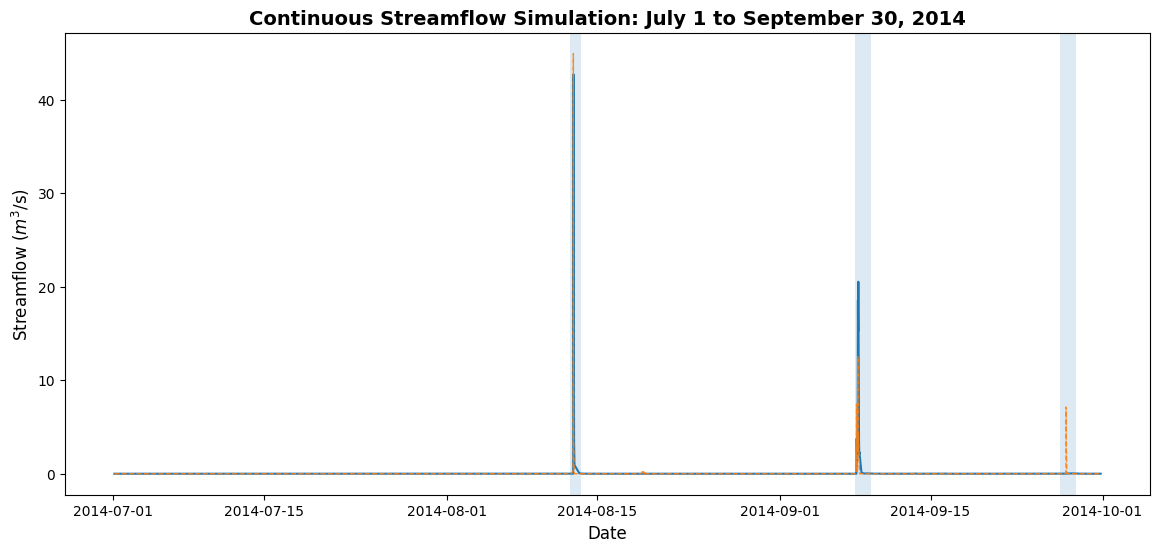

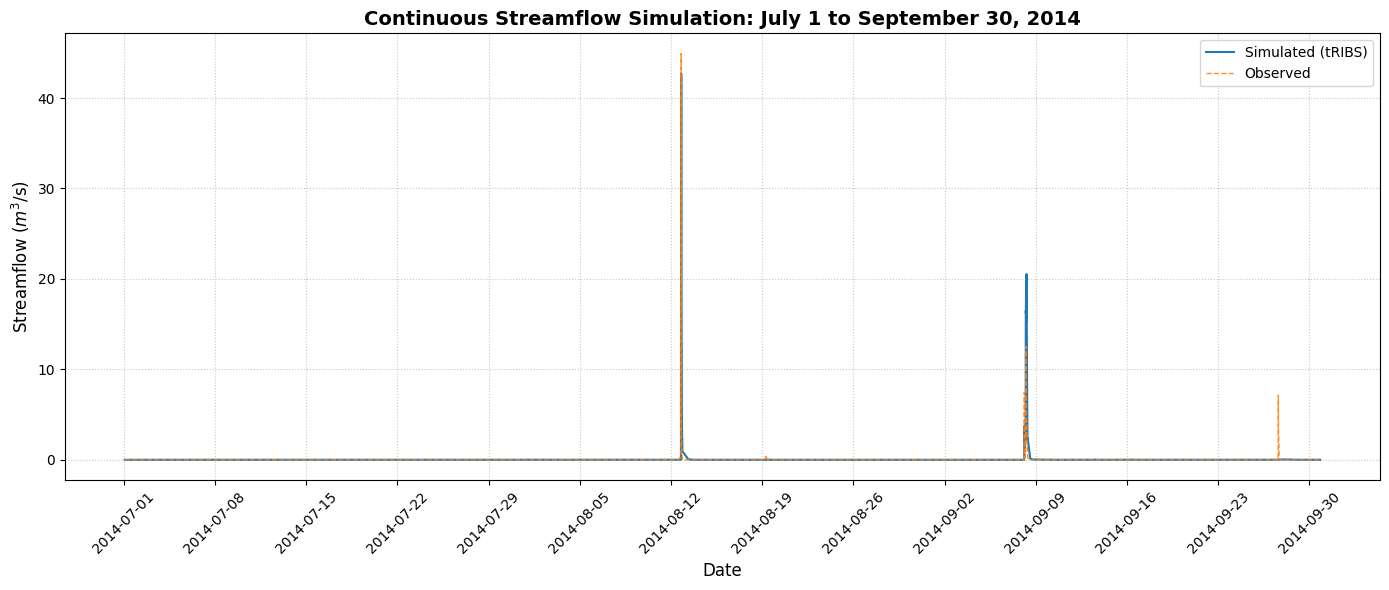

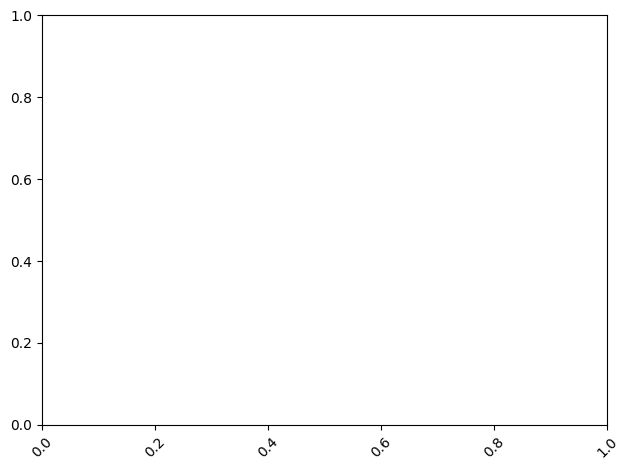

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(compare_df.index, compare_df['Simulated'],
        linewidth=1.5, label='Simulated (tRIBS)')
ax.plot(compare_df.index, compare_df['Observed'],
        linewidth=1.0, linestyle='--', alpha=0.9, label='Observed')

# Shade the three analysis events
for event_name, (start, end) in event_windows.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, label=event_name)

# Clean duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
seen = set()
new_handles, new_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        new_handles.append(h)
        new_labels.append(l)
        seen.add(l)

ax.set_title('Continuous Streamflow Simulation: July 1 to September 30, 2014',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Streamflow ($m^3$/s)', fontsize=12)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(compare_df.index, compare_df['Simulated'],
        linewidth=1.5, label='Simulated (tRIBS)')
ax.plot(compare_df.index, compare_df['Observed'],
        linewidth=1.0, linestyle='--', alpha=0.9, label='Observed')

ax.set_title('Continuous Streamflow Simulation: July 1 to September 30, 2014',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Streamflow ($m^3$/s)', fontsize=12)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(new_handles, new_labels, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

tRIBS has many model outputs. One of those is spatial outputs. For this sandbox environment the integrated spatial output file has outputs like time invariant watershed properties but also cumulative outputs of flux variable like evapotranspiration.

First spatial plot we will make is the voronoi polygon elevation map:

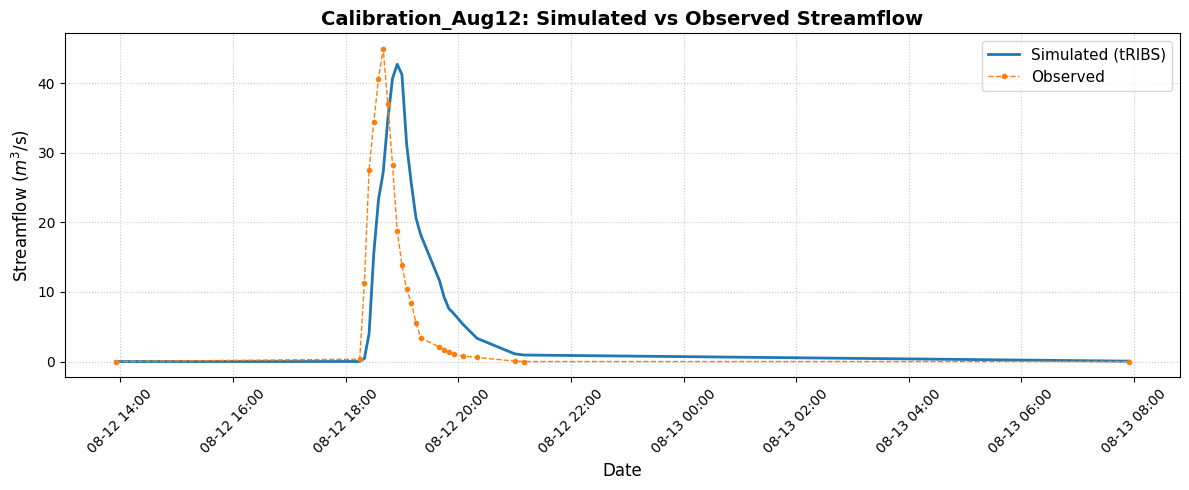

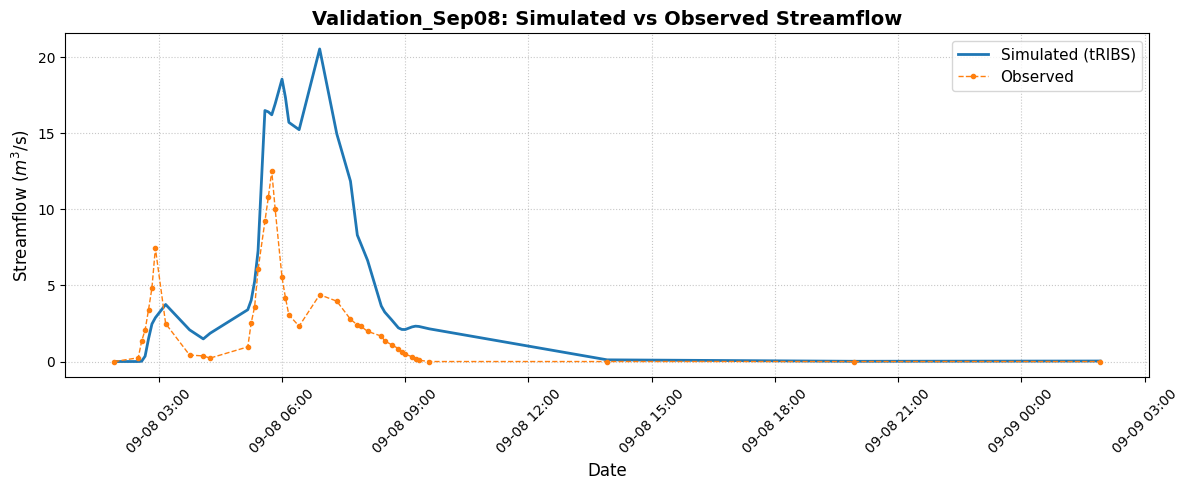

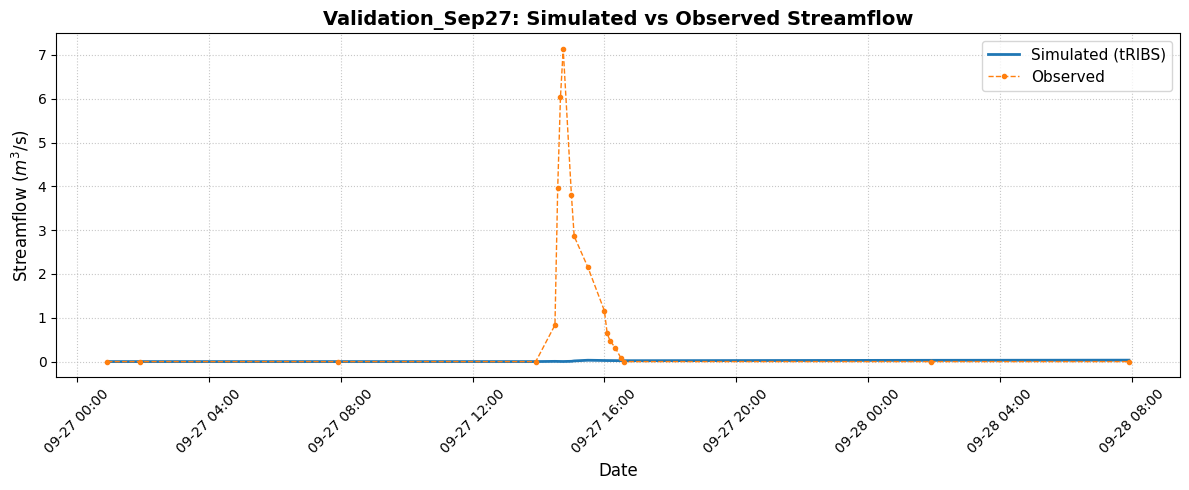

In [8]:
for event_name, (event_start, event_end) in event_windows.items():
    event_df = compare_df.loc[event_start:event_end].dropna().copy()

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(event_df.index, event_df['Simulated'],
            linewidth=2, label='Simulated (tRIBS)')
    ax.plot(event_df.index, event_df['Observed'],
            linestyle='--', marker='o', markersize=3, linewidth=1,
            label='Observed')

    ax.set_title(f'{event_name}: Simulated vs Observed Streamflow',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Streamflow ($m^3$/s)', fontsize=12)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)

    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

Notice in the plot above how the lower Voronoi polygon ID values are all along the ridgeline boundary and the channels all have high values. This is how tRIBS assign the ID values, lower values are computed first i.e. they don't have an upstream neighbor that is giving them water.

Next we can plot the cumulative ET for the entire 480 hour simulaiton

In [9]:
import numpy as np
import pandas as pd

for event_name, (metric_start, metric_end) in metric_windows.items():
    event_df = compare_df.loc[metric_start:metric_end].dropna().copy()

    print(f"\n===== {event_name} =====")
    print(f"Window: {metric_start} --> {metric_end}")
    print(f"Rows in event_df: {len(event_df)}")

    if len(event_df) < 2:
        print("Not enough data points in this event window to compute metrics.")
        print("Check the metric window or whether Observed/Simulated overlap in this period.")
        continue

    obs = event_df['Observed']
    sim = event_df['Simulated']

    obs_peak = obs.max()
    sim_peak = sim.max()

    obs_tpeak = obs.idxmax()
    sim_tpeak = sim.idxmax()

    dt_seconds = (event_df.index[1] - event_df.index[0]).total_seconds()
    obs_vol_m3 = obs.sum() * dt_seconds
    sim_vol_m3 = sim.sum() * dt_seconds

    vol_error_pct = ((sim_vol_m3 - obs_vol_m3) / obs_vol_m3) * 100 if obs_vol_m3 != 0 else np.nan

    rmse = np.sqrt(np.mean((sim - obs)**2))
    nse = 1 - (np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2)) if np.sum((obs - obs.mean())**2) != 0 else np.nan
    pbias = 100 * (np.sum(sim - obs) / np.sum(obs)) if np.sum(obs) != 0 else np.nan

    print("--- HYDROLOGICAL EVENT METRICS ---")
    print(f"Observed Peak Flow: {obs_peak:.2f} m^3/s  (at {obs_tpeak.strftime('%m-%d %H:%M')})")
    print(f"Simulated Peak Flow:{sim_peak:.2f} m^3/s  (at {sim_tpeak.strftime('%m-%d %H:%M')})")
    print(f"Peak Timing Error:  {(sim_tpeak - obs_tpeak).total_seconds() / 3600:.1f} hours\n")

    print(f"Observed Volume:    {obs_vol_m3:,.0f} m^3")
    print(f"Simulated Volume:   {sim_vol_m3:,.0f} m^3")
    print(f"Volume Error:       {vol_error_pct:+.1f}%\n")

    print("--- STATISTICAL PERFORMANCE ---")
    print(f"RMSE:               {rmse:.2f} m^3/s")
    print(f"NSE:                {nse:.3f}")
    print(f"Percent Bias:       {pbias:+.1f}%")

NameError: name 'metric_windows' is not defined

Interestingly the model has some pretty large differences in cumulative ET. The plot of depth to bedrock was added as one way of getting to an explanation. Since the soils are so shallow on the mountainous slopes the vegetation in those areas has full access to any soil water available.

Another coomonly used model output is the mean response file (`*.mrf`). This output is a timeseries of many of the model's important variables. In the plot below we include the 

In [ ]:
for _, row in metrics_df.iterrows():
    print("=" * 60)
    print(row['Event'])
    print("=" * 60)
    print(f"Observed Peak Flow:   {row['Obs Peak (m3/s)']:.2f} m^3/s")
    print(f"Simulated Peak Flow:  {row['Sim Peak (m3/s)']:.2f} m^3/s")
    print(f"Peak Timing Error:    {row['Peak Timing Error (hr)']:+.2f} hr")
    print(f"Observed Volume:      {row['Obs Volume (m3)']:,.0f} m^3")
    print(f"Simulated Volume:     {row['Sim Volume (m3)']:,.0f} m^3")
    print(f"Volume Error:         {row['Volume Error (%)']:+.1f}%")
    print(f"RMSE:                 {row['RMSE (m3/s)']:.2f} m^3/s")
    print(f"NSE:                  {row['NSE']:.3f}")
    print(f"PBIAS:                {row['PBIAS (%)']:+.1f}%")
    print()

NameError: name 'metrics_df' is not defined

Here we plotted to the groundwater depth from mrf file only the lower axis and mean areal precipitation on the top axis. We can see with the shallow depth to bedrock the soil is almost instantly saturated.

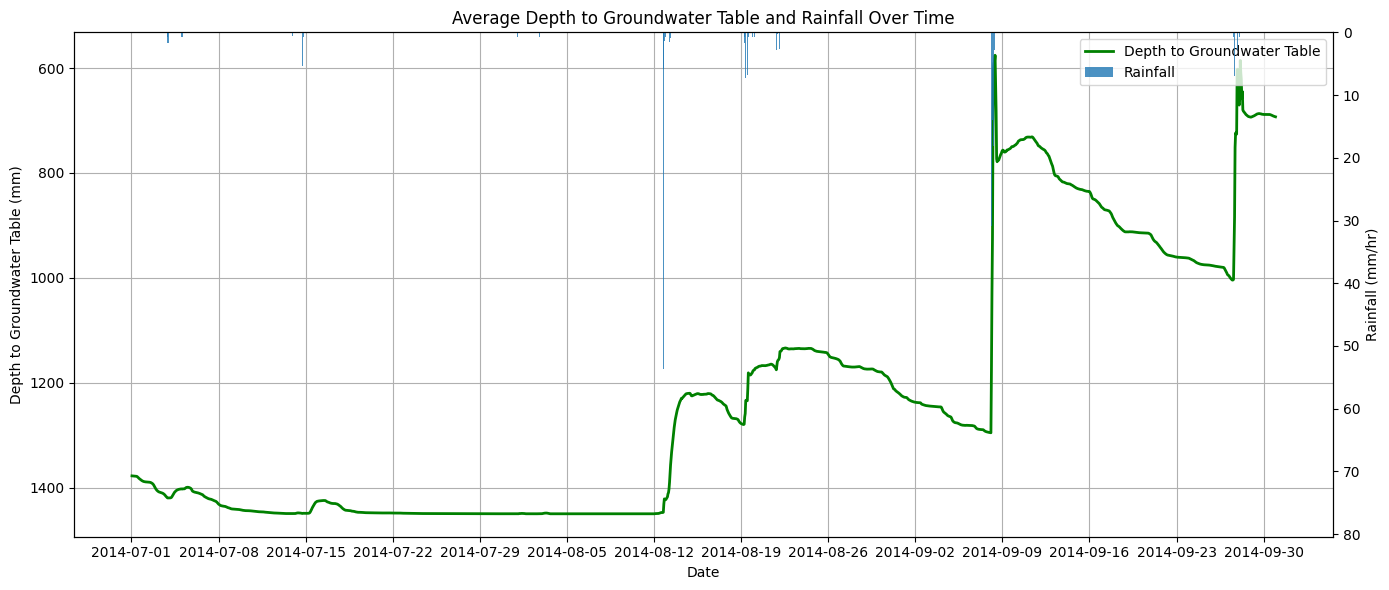

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

mrf_plot = mrf.copy()
mrf_plot.index = pd.to_datetime(mrf_plot.index)
mrf_plot = mrf_plot.loc['2014-07-01':'2014-09-30'].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Groundwater depth on left axis
ax1.plot(
    mrf_plot.index,
    mrf_plot['MDGW'],
    linewidth=2,
    color='green',
    label='Depth to Groundwater Table'
)
ax1.set_xlabel('Date')
ax1.set_ylabel('Depth to Groundwater Table (mm)')
ax1.invert_yaxis()
ax1.grid(True)

# Rainfall on right axis
ax2 = ax1.twinx()
ax2.bar(
    mrf_plot.index,
    mrf_plot['MAP'],
    width=0.06,
    alpha=0.8,
    label='Rainfall'
)
ax2.set_ylabel('Rainfall (mm/hr)')
ax2.invert_yaxis()

max_rain = mrf_plot['MAP'].max()
if pd.notna(max_rain) and max_rain > 0:
    ax2.set_ylim(max_rain * 1.5, 0)

ax1.set_title('Average Depth to Groundwater Table and Rainfall Over Time')

ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

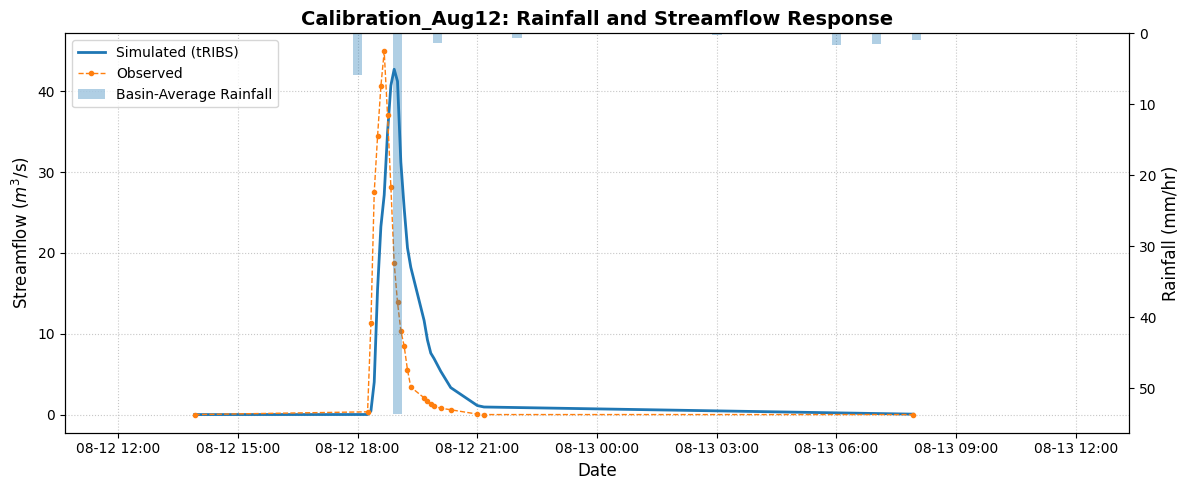

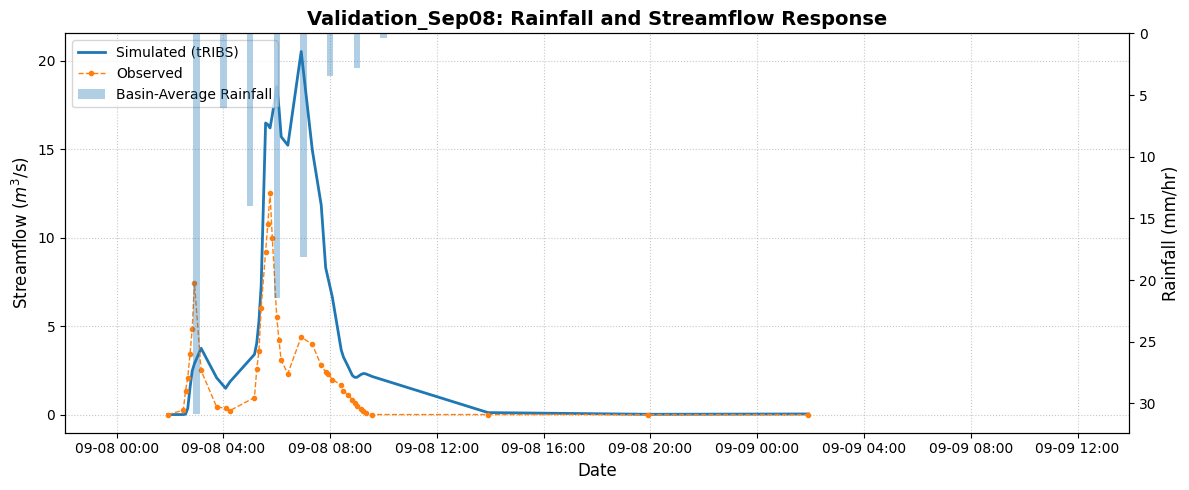

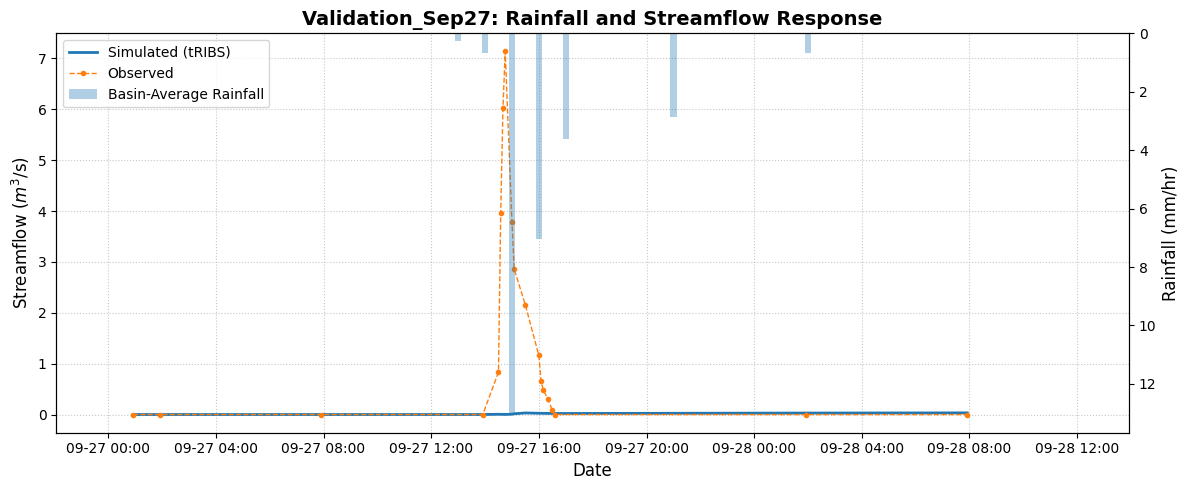

In [11]:
mrf_plot = mrf.copy()
mrf_plot.index = pd.to_datetime(mrf_plot.index)

for event_name, (event_start, event_end) in event_windows.items():
    event_df = compare_df.loc[event_start:event_end].dropna().copy()
    event_mrf = mrf_plot.loc[event_start:event_end].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # streamflow
    ax1.plot(event_df.index, event_df['Simulated'],
             linewidth=2, label='Simulated (tRIBS)')
    ax1.plot(event_df.index, event_df['Observed'],
             linestyle='--', marker='o', markersize=3, linewidth=1,
             label='Observed')
    ax1.set_ylabel('Streamflow ($m^3$/s)', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # rainfall
    ax2 = ax1.twinx()
    ax2.bar(event_mrf.index, event_mrf['MAP'],
            width=0.01, alpha=0.35, label='Basin-Average Rainfall')
    ax2.set_ylabel('Rainfall (mm/hr)', fontsize=12)
    ax2.invert_yaxis()

    ax1.set_title(f'{event_name}: Rainfall and Streamflow Response',
                  fontsize=14, fontweight='bold')

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.tight_layout()
    plt.show()

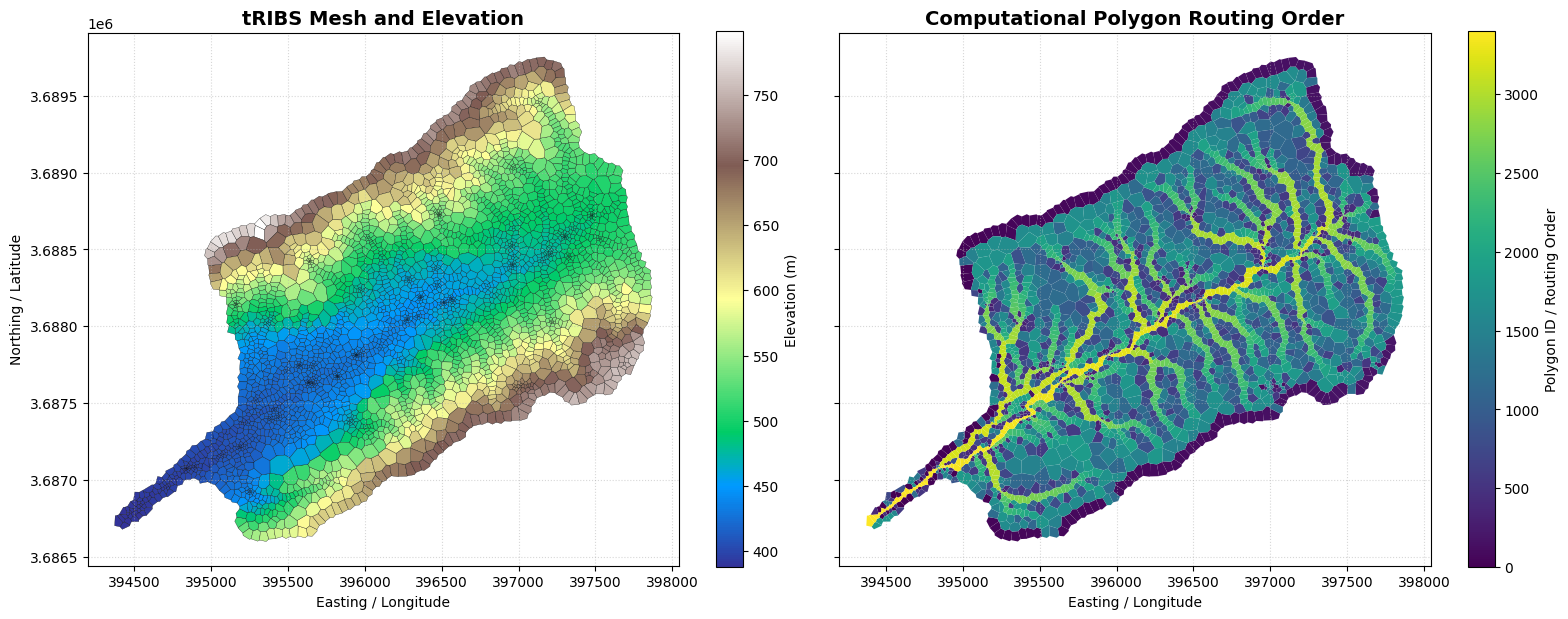

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Mesh + elevation
gdf.plot(
    ax=ax1,
    column='Z',
    cmap='terrain',
    edgecolor='black',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': 'Elevation (m)', 'shrink': 0.8}
)
ax1.set_title('tRIBS Mesh and Elevation', fontsize=14, fontweight='bold')
ax1.set_xlabel('Easting / Longitude')
ax1.set_ylabel('Northing / Latitude')
ax1.grid(True, linestyle=':', alpha=0.5)

# Routing order / polygon IDs
gdf.plot(
    ax=ax2,
    column='ID',
    cmap='viridis',
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Polygon ID / Routing Order', 'shrink': 0.8}
)
ax2.set_title('Computational Polygon Routing Order', fontsize=14, fontweight='bold')
ax2.set_xlabel('Easting / Longitude')
ax2.set_yticklabels([])
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

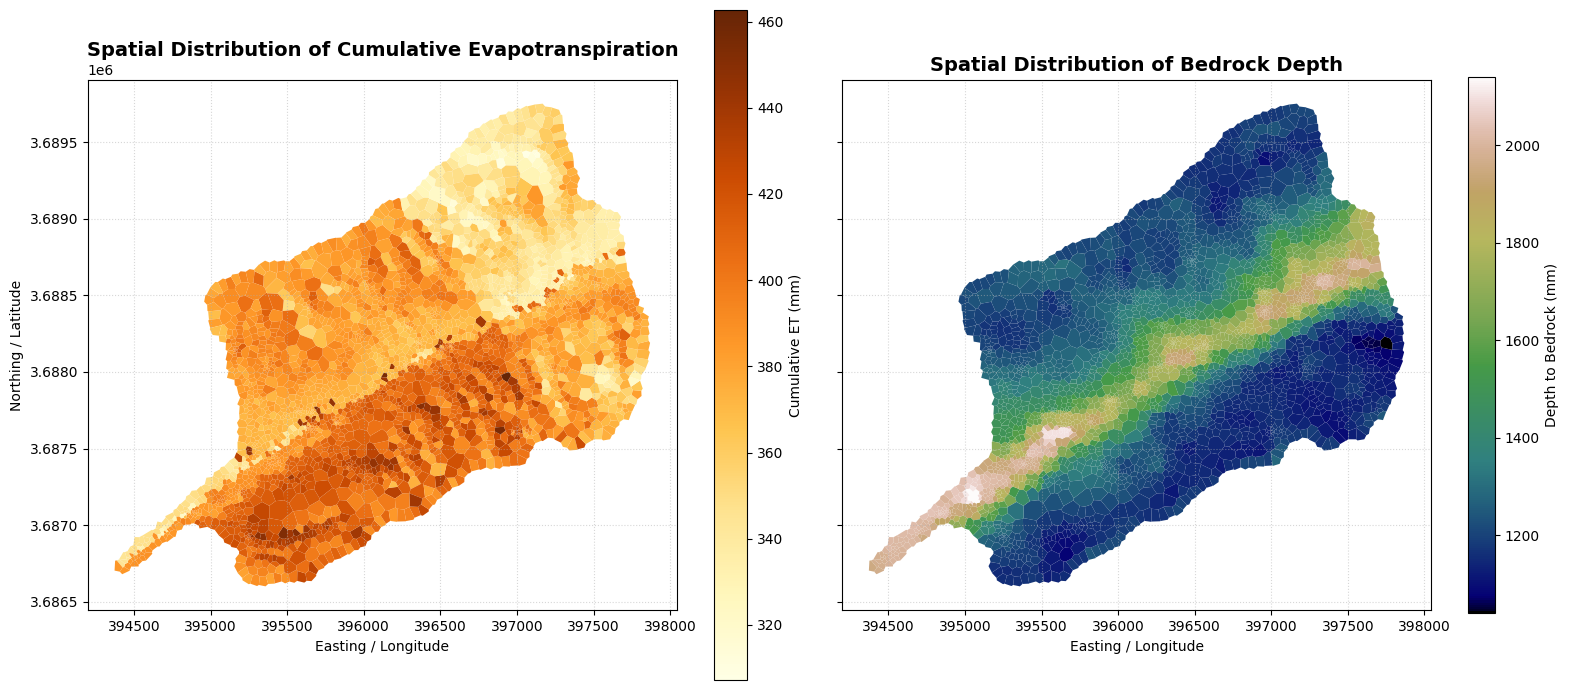

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Cumulative ET
gdf.plot(
    ax=ax1,
    column='cET',
    cmap='YlOrBr',
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Cumulative ET (mm)', 'orientation': 'vertical'}
)
ax1.set_title('Spatial Distribution of Cumulative Evapotranspiration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Easting / Longitude')
ax1.set_ylabel('Northing / Latitude')
ax1.grid(True, linestyle=':', alpha=0.5)

# Bedrock depth
gdf.plot(
    ax=ax2,
    column='Bedrock_Depth_mm',
    cmap='gist_earth',
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Depth to Bedrock (mm)', 'shrink': 0.8}
)
ax2.set_title('Spatial Distribution of Bedrock Depth', fontsize=14, fontweight='bold')
ax2.set_xlabel('Easting / Longitude')
ax2.set_yticklabels([])
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

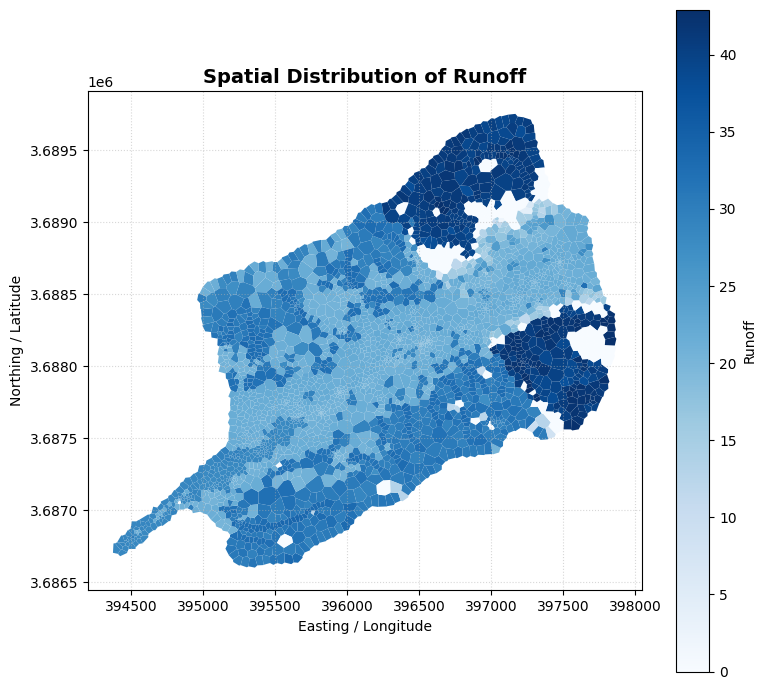

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))

gdf.plot(
    ax=ax,
    column='HRt',
    cmap='Blues',
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Runoff', 'orientation': 'vertical'}
)

ax.set_title('Spatial Distribution of Runoff', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting / Longitude')
ax.set_ylabel('Northing / Latitude')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd

metric_windows = {
    'Calibration_Aug12': ('2014-08-12 18:15', '2014-08-12 21:00'),
    'Validation_Sep08':  ('2014-09-08 02:00', '2014-09-08 10:00'),
    'Validation_Sep27':  ('2014-09-27 15:00', '2014-09-27 22:00'),
}

metrics_list = []

for event_name, (metric_start, metric_end) in metric_windows.items():
    event_df = compare_df.loc[metric_start:metric_end].dropna().copy()

    print(f"\n===== {event_name} =====")
    print(f"Window: {metric_start} --> {metric_end}")
    print(f"Rows in event_df: {len(event_df)}")

    if len(event_df) < 2:
        print("Not enough data points in this event window to compute metrics.")
        print("Widen this metric window.")
        metrics_list.append({
            'Event': event_name,
            'Rows': len(event_df),
            'Obs Peak (m3/s)': np.nan,
            'Sim Peak (m3/s)': np.nan,
            'Peak Error (%)': np.nan,
            'Peak Timing Error (hr)': np.nan,
            'Obs Volume (m3)': np.nan,
            'Sim Volume (m3)': np.nan,
            'Volume Error (%)': np.nan,
            'Obs Duration (hr)': np.nan,
            'Sim Duration (hr)': np.nan,
            'RMSE (m3/s)': np.nan,
            'NSE': np.nan,
            'PBIAS (%)': np.nan
        })
        continue

    obs = event_df['Observed']
    sim = event_df['Simulated']

    obs_peak = obs.max()
    sim_peak = sim.max()

    obs_tpeak = obs.idxmax()
    sim_tpeak = sim.idxmax()

    peak_error_pct = ((sim_peak - obs_peak) / obs_peak) * 100 if obs_peak != 0 else np.nan
    peak_timing_hr = (sim_tpeak - obs_tpeak).total_seconds() / 3600.0

    dt_seconds = (event_df.index[1] - event_df.index[0]).total_seconds()
    obs_vol_m3 = obs.sum() * dt_seconds
    sim_vol_m3 = sim.sum() * dt_seconds
    vol_error_pct = ((sim_vol_m3 - obs_vol_m3) / obs_vol_m3) * 100 if obs_vol_m3 != 0 else np.nan

    obs_mean = obs.mean()
    sim_mean = sim.mean()

    if (obs > 0).any():
        obs_first_flow = obs[obs > 0].index.min()
        obs_last_flow = obs[obs > 0].index.max()
        obs_duration_hr = (obs_last_flow - obs_first_flow).total_seconds() / 3600.0
        obs_rise_time_hr = (obs_tpeak - obs_first_flow).total_seconds() / 3600.0
    else:
        obs_first_flow = pd.NaT
        obs_duration_hr = np.nan
        obs_rise_time_hr = np.nan

    if (sim > 0).any():
        sim_first_flow = sim[sim > 0].index.min()
        sim_last_flow = sim[sim > 0].index.max()
        sim_duration_hr = (sim_last_flow - sim_first_flow).total_seconds() / 3600.0
        sim_rise_time_hr = (sim_tpeak - sim_first_flow).total_seconds() / 3600.0
    else:
        sim_first_flow = pd.NaT
        sim_duration_hr = np.nan
        sim_rise_time_hr = np.nan

    rmse = np.sqrt(np.mean((sim - obs) ** 2))
    nse_denom = np.sum((obs - obs.mean()) ** 2)
    nse = 1 - (np.sum((sim - obs) ** 2) / nse_denom) if nse_denom != 0 else np.nan
    pbias = 100 * (np.sum(sim - obs) / np.sum(obs)) if np.sum(obs) != 0 else np.nan

    print("--- HYDROLOGICAL EVENT METRICS ---")
    print(f"Observed Peak Flow:   {obs_peak:.2f} m^3/s  (at {obs_tpeak.strftime('%m-%d %H:%M')})")
    print(f"Simulated Peak Flow:  {sim_peak:.2f} m^3/s  (at {sim_tpeak.strftime('%m-%d %H:%M')})")
    print(f"Peak Flow Error:      {peak_error_pct:+.1f}%")
    print(f"Peak Timing Error:    {peak_timing_hr:+.2f} hours")
    print()
    print(f"Observed Volume:      {obs_vol_m3:,.0f} m^3")
    print(f"Simulated Volume:     {sim_vol_m3:,.0f} m^3")
    print(f"Volume Error:         {vol_error_pct:+.1f}%")
    print()
    print("--- HYDROGRAPH SHAPE METRICS ---")
    print(f"Observed Mean Flow:   {obs_mean:.2f} m^3/s")
    print(f"Simulated Mean Flow:  {sim_mean:.2f} m^3/s")
    if pd.notna(obs_first_flow):
        print(f"Observed First Flow:  {obs_first_flow.strftime('%m-%d %H:%M')}")
    else:
        print("Observed First Flow:  none")
    if pd.notna(sim_first_flow):
        print(f"Simulated First Flow: {sim_first_flow.strftime('%m-%d %H:%M')}")
    else:
        print("Simulated First Flow: none")
    print(f"Observed Duration:    {obs_duration_hr:.2f} hr")
    print(f"Simulated Duration:   {sim_duration_hr:.2f} hr")
    print(f"Observed Rise Time:   {obs_rise_time_hr:.2f} hr")
    print(f"Simulated Rise Time:  {sim_rise_time_hr:.2f} hr")
    print()
    print("--- STATISTICAL PERFORMANCE ---")
    print(f"RMSE:                 {rmse:.2f} m^3/s")
    print(f"NSE:                  {nse:.3f}")
    print(f"Percent Bias:         {pbias:+.1f}%")

    metrics_list.append({
        'Event': event_name,
        'Rows': len(event_df),
        'Obs Peak (m3/s)': obs_peak,
        'Sim Peak (m3/s)': sim_peak,
        'Peak Error (%)': peak_error_pct,
        'Peak Timing Error (hr)': peak_timing_hr,
        'Obs Volume (m3)': obs_vol_m3,
        'Sim Volume (m3)': sim_vol_m3,
        'Volume Error (%)': vol_error_pct,
        'Obs Duration (hr)': obs_duration_hr,
        'Sim Duration (hr)': sim_duration_hr,
        'RMSE (m3/s)': rmse,
        'NSE': nse,
        'PBIAS (%)': pbias
    })

metrics_df = pd.DataFrame(metrics_list)

print("\n\n===== SUMMARY TABLE =====")
print(metrics_df.round({
    'Obs Peak (m3/s)': 2,
    'Sim Peak (m3/s)': 2,
    'Peak Error (%)': 1,
    'Peak Timing Error (hr)': 2,
    'Obs Volume (m3)': 0,
    'Sim Volume (m3)': 0,
    'Volume Error (%)': 1,
    'Obs Duration (hr)': 2,
    'Sim Duration (hr)': 2,
    'RMSE (m3/s)': 2,
    'NSE': 3,
    'PBIAS (%)': 1
}))


===== Calibration_Aug12 =====
Window: 2014-08-12 18:15 --> 2014-08-12 21:00
Rows in event_df: 21
--- HYDROLOGICAL EVENT METRICS ---
Observed Peak Flow:   44.91 m^3/s  (at 08-12 18:40)
Simulated Peak Flow:  42.71 m^3/s  (at 08-12 18:55)
Peak Flow Error:      -4.9%
Peak Timing Error:    +0.25 hours

Observed Volume:      87,669 m^3
Simulated Volume:     111,192 m^3
Volume Error:         +26.8%

--- HYDROGRAPH SHAPE METRICS ---
Observed Mean Flow:   13.92 m^3/s
Simulated Mean Flow:  17.65 m^3/s
Observed First Flow:  08-12 18:15
Simulated First Flow: 08-12 18:15
Observed Duration:    2.75 hr
Simulated Duration:   2.75 hr
Observed Rise Time:   0.42 hr
Simulated Rise Time:  0.67 hr

--- STATISTICAL PERFORMANCE ---
RMSE:                 14.73 m^3/s
NSE:                  0.012
Percent Bias:         +26.8%

===== Validation_Sep08 =====
Window: 2014-09-08 02:00 --> 2014-09-08 10:00
Rows in event_df: 38
--- HYDROLOGICAL EVENT METRICS ---
Observed Peak Flow:   12.52 m^3/s  (at 09-08 05:45)
Simula